# Multi-Task Learning for Speech Emotion Recognition

### Jason Clark

---

## Problem Statement

**Goal**: Improve emotion classification by **jointly learning** auxiliary tasks (gender, intensity, speaker) that provide additional supervision signals.


## 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import glob
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0+cu128
Device: cuda


## 2. Data Loading with All Labels

In [ ]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Data directory in Google Drive
DATA_DIR = Path("/content/drive/MyDrive/Speech-Emotion-Recognition-/data")

EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}
INTENSITY_MAP = {"01": "normal", "02": "strong"}

def parse_ravdess_filename(filepath):
    name = Path(filepath).stem
    parts = name.split("-")
    if len(parts) != 7:
        return None
    actor_id = int(parts[6])
    return {
        "file_path": filepath,
        "emotion": EMOTION_MAP.get(parts[2]),
        "intensity": INTENSITY_MAP.get(parts[3]),
        "actor_id": parts[6],
        "gender": "male" if actor_id % 2 == 1 else "female",
    }

wav_paths = sorted(glob.glob(str(DATA_DIR / "Actor_*" / "*.wav")))
rows = [r for r in (parse_ravdess_filename(p) for p in wav_paths) if r]
df = pd.DataFrame(rows)

print(f"Dataset size: {len(df)}")
print(f"\nLabel distributions:")
print(f"Emotions: {df['emotion'].nunique()}, Genders: {df['gender'].nunique()}")
print(f"Intensities: {df['intensity'].nunique()}, Speakers: {df['actor_id'].nunique()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset size: 1440

Label distributions:
Emotions: 8, Genders: 2
Intensities: 2, Speakers: 24


## 3. Feature Extraction

In [ ]:
SAMPLE_RATE = 22050
N_MELS = 64
MAX_TIME_FRAMES = 128

def extract_mel_spectrogram(file_path):
    try:
        y, _ = librosa.load(file_path, sr=SAMPLE_RATE)

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=SAMPLE_RATE,
            n_mels=N_MELS,
            n_fft=2048,
            hop_length=512
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Pad / truncate
        if mel_db.shape[1] < MAX_TIME_FRAMES:
            mel_db = np.pad(
                mel_db,
                ((0, 0), (0, MAX_TIME_FRAMES - mel_db.shape[1])),
                mode='constant'
            )
        else:
            mel_db = mel_db[:, :MAX_TIME_FRAMES]

        return mel_db

    except Exception:
        return None

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("Extracting features in parallel...")

def process_row(row):
    try:
        mel = extract_mel_spectrogram(row['file_path'])

        if mel is None:
            return None

        return (
            mel,
            row['emotion'],
            row['gender'],
            row['intensity'],
            row['actor_id']
        )

    except Exception as e:
        return None

rows = [row for _, row in df.iterrows()]

results = []

with ThreadPoolExecutor() as executor:
    for result in tqdm(executor.map(process_row, rows), total=len(rows)):
        if result is not None:
            results.append(result)

# Build features + labels ONLY from successful rows
X = np.array([r[0] for r in results])[:, np.newaxis, :, :]

labels = {
    'emotion': [r[1] for r in results],
    'gender': [r[2] for r in results],
    'intensity': [r[3] for r in results],
    'speaker': [r[4] for r in results]
}

# Normalize
X_min, X_max = X.min(), X.max()
X_norm = (
    X - X.mean(axis=(2,3), keepdims=True)
) / (
    X.std(axis=(2,3), keepdims=True) + 1e-8
)

# Encode labels
encoders = {}
encoded_labels = {}

for task in labels.keys():
    encoders[task] = LabelEncoder()
    encoded_labels[task] = encoders[task].fit_transform(labels[task])
    print(f"{task}: {len(encoders[task].classes_)} classes")

print(f"\nFeatures shape: {X.shape}")
print(f"Successful samples: {len(X)}")

Extracting features in parallel...


100%|██████████| 1440/1440 [00:04<00:00, 347.30it/s]


emotion: 8 classes
gender: 2 classes
intensity: 2 classes
speaker: 24 classes

Features shape: (1440, 1, 64, 128)
Successful samples: 1440


In [ ]:
# Split data
indices = np.arange(len(X))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED,
                                        stratify=encoded_labels['emotion'])
train_idx, val_idx = train_test_split(train_idx, test_size=0.15, random_state=SEED)

X_train, X_val, X_test = X_norm[train_idx], X_norm[val_idx], X_norm[test_idx]

y_train = {task: encoded_labels[task][train_idx] for task in encoded_labels}
y_val = {task: encoded_labels[task][val_idx] for task in encoded_labels}
y_test = {task: encoded_labels[task][test_idx] for task in encoded_labels}

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 979, Val: 173, Test: 288


## 4. Multi-Task Dataset

In [ ]:
import random
import torch

def spec_augment(spec,
                 freq_mask_param=8,
                 time_mask_param=16,
                 num_freq_masks=2,
                 num_time_masks=2):
    """
    spec shape: (1, H, W)
    """

    spec = spec.clone()

    _, H, W = spec.shape

    # Frequency masking
    for _ in range(num_freq_masks):
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, max(0, H - f))

        spec[:, f0:f0+f, :] = 0

    # Time masking
    for _ in range(num_time_masks):
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, max(0, W - t))

        spec[:, :, t0:t0+t] = 0

    return spec

In [ ]:
from torch.utils.data import Dataset

class MultiTaskDataset(Dataset):
    def __init__(self, X, y_dict, augment=False):
        self.X = torch.FloatTensor(X)

        self.y_emotion = torch.LongTensor(y_dict['emotion'])
        self.y_gender = torch.LongTensor(y_dict['gender'])
        self.y_intensity = torch.LongTensor(y_dict['intensity'])
        self.y_speaker = torch.LongTensor(y_dict['speaker'])

        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = self.X[idx]

        # Apply SpecAugment ONLY during training
        if self.augment:
            x = spec_augment(x)

        return (
            x,
            self.y_emotion[idx],
            self.y_gender[idx],
            self.y_intensity[idx],
            self.y_speaker[idx]
        )

BATCH_SIZE = 32

train_loader = DataLoader(
    MultiTaskDataset(X_train, y_train, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    MultiTaskDataset(X_val, y_val, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    MultiTaskDataset(X_test, y_test, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False
)

## 5. Multi-Task Model

In [ ]:
import torch
import torch.nn as nn

class CNNTransformerMultiTask(nn.Module):
    def __init__(
        self,
        n_emotions,
        n_genders,
        n_intensities,
        n_speakers,
        d_model=128,
        nhead=4,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        # =========================
        # CNN Feature Extractor
        # =========================
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, d_model, kernel_size=3, padding=1),
            nn.BatchNorm2d(d_model),
            nn.ReLU(),
            nn.Dropout2d(0.2)
        )

        # =========================
        # Transformer Encoder
        # =========================
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # =========================
        # Shared Dense Layer
        # =========================
        self.shared_fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # =========================
        # Task Heads
        # =========================
        self.emotion_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_emotions)
        )

        self.gender_head = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, n_genders)
        )

        self.intensity_head = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, n_intensities)
        )

        self.speaker_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_speakers)
        )

    def forward(self, x):

        # =========================
        # CNN Feature Extraction
        # Input: (B, 1, H, W)
        # =========================
        x = self.cnn(x)

        # Shape after CNN:
        # (B, C, H, W)

        B, C, H, W = x.shape

        # =========================
        # Convert to Sequence
        # =========================
        # (B, C, H, W)
        # -> (B, H*W, C)

        x = x.permute(0, 2, 3, 1)
        x = x.reshape(B, H * W, C)

        # =========================
        # Transformer Encoding
        # =========================
        x = self.transformer(x)

        # Global average pooling over sequence dimension
        x = x.mean(dim=1)

        # Shared representation
        shared = self.shared_fc(x)

        # =========================
        # Multi-Task Outputs
        # =========================
        outputs = {
            'emotion': self.emotion_head(shared),
            'gender': self.gender_head(shared),
            'intensity': self.intensity_head(shared),
            'speaker': self.speaker_head(shared)
        }

        return outputs


# ============================================
# Initialize Model
# ============================================

n_emotions = len(encoders['emotion'].classes_)
n_genders = len(encoders['gender'].classes_)
n_intensities = len(encoders['intensity'].classes_)
n_speakers = len(encoders['speaker'].classes_)

model = CNNTransformerMultiTask(
    n_emotions=n_emotions,
    n_genders=n_genders,
    n_intensities=n_intensities,
    n_speakers=n_speakers,
    d_model=128,
    nhead=4,
    num_layers=2,
    dropout=0.3
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

CNNTransformerMultiTask(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout2d(p=0.2, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (

## 6. Training

In [ ]:
# Loss weights
LOSS_WEIGHTS = {'emotion': 2.0, 'gender': 0.3, 'intensity': 1.0, 'speaker': 0.5}

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=7)


def train_epoch(model, loader, criterion, optimizer, device, weights):
    model.train()
    losses = {task: 0 for task in weights}
    correct = {task: 0 for task in weights}
    total = 0

    for X, y_em, y_ge, y_in, y_sp in loader:
        X = X.to(device)
        targets = {'emotion': y_em.to(device), 'gender': y_ge.to(device),
                   'intensity': y_in.to(device), 'speaker': y_sp.to(device)}

        optimizer.zero_grad()
        outputs = model(X)

        total_loss = 0
        for task in weights:
            loss = criterion(outputs[task], targets[task])
            total_loss += weights[task] * loss
            losses[task] += loss.item()

            _, pred = outputs[task].max(1)
            correct[task] += pred.eq(targets[task]).sum().item()

        total_loss.backward()
        optimizer.step()
        total += X.size(0)

    return {task: losses[task] / len(loader) for task in weights}, \
           {task: correct[task] / total for task in weights}


def evaluate(model, loader, criterion, device, weights):
    model.eval()
    losses = {task: 0 for task in weights}
    correct = {task: 0 for task in weights}
    total = 0

    with torch.no_grad():
        for X, y_em, y_ge, y_in, y_sp in loader:
            X = X.to(device)
            targets = {'emotion': y_em.to(device), 'gender': y_ge.to(device),
                       'intensity': y_in.to(device), 'speaker': y_sp.to(device)}

            outputs = model(X)

            for task in weights:
                loss = criterion(outputs[task], targets[task])
                losses[task] += loss.item()
                _, pred = outputs[task].max(1)
                correct[task] += pred.eq(targets[task]).sum().item()

            total += X.size(0)

    return {task: losses[task] / len(loader) for task in weights}, \
           {task: correct[task] / total for task in weights}

In [ ]:
NUM_EPOCHS = 100
PATIENCE = 200
best_val_acc = 0
patience_counter = 0

history = {f'{split}_{task}': [] for split in ['train', 'val']
           for task in ['emotion', 'gender', 'intensity', 'speaker']}

print("Starting multi-task training...")
for epoch in range(NUM_EPOCHS):
    train_losses, train_accs = train_epoch(model, train_loader, criterion, optimizer, device, LOSS_WEIGHTS)
    val_losses, val_accs = evaluate(model, val_loader, criterion, device, LOSS_WEIGHTS)

    scheduler.step(val_accs['emotion'])

    for task in LOSS_WEIGHTS:
        history[f'train_{task}'].append(train_accs[task])
        history[f'val_{task}'].append(val_accs[task])

    if val_accs['emotion'] > best_val_acc:
        best_val_acc = val_accs['emotion']
        patience_counter = 0
        torch.save(model.state_dict(), 'best_multitask_model.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
              f"Emotion: {val_accs['emotion']:.4f}, Gender: {val_accs['gender']:.4f}, "
              f"Intensity: {val_accs['intensity']:.4f}, Speaker: {val_accs['speaker']:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_multitask_model.pt'))
print("\nTraining complete!")

Starting multi-task training...
Epoch 10/100 - Emotion: 0.2832, Gender: 0.8208, Intensity: 0.6936, Speaker: 0.1098
Epoch 20/100 - Emotion: 0.3815, Gender: 0.8324, Intensity: 0.7110, Speaker: 0.1618
Epoch 30/100 - Emotion: 0.4393, Gender: 0.8902, Intensity: 0.7341, Speaker: 0.1965
Epoch 40/100 - Emotion: 0.4451, Gender: 0.8786, Intensity: 0.7688, Speaker: 0.1792
Epoch 50/100 - Emotion: 0.4566, Gender: 0.9075, Intensity: 0.7688, Speaker: 0.2428
Epoch 60/100 - Emotion: 0.5029, Gender: 0.9249, Intensity: 0.7688, Speaker: 0.1965
Epoch 70/100 - Emotion: 0.5029, Gender: 0.9133, Intensity: 0.7803, Speaker: 0.2023
Epoch 80/100 - Emotion: 0.5029, Gender: 0.9538, Intensity: 0.7688, Speaker: 0.1908
Epoch 90/100 - Emotion: 0.5434, Gender: 0.9422, Intensity: 0.7688, Speaker: 0.2428
Epoch 100/100 - Emotion: 0.5607, Gender: 0.9480, Intensity: 0.7630, Speaker: 0.2312

Training complete!


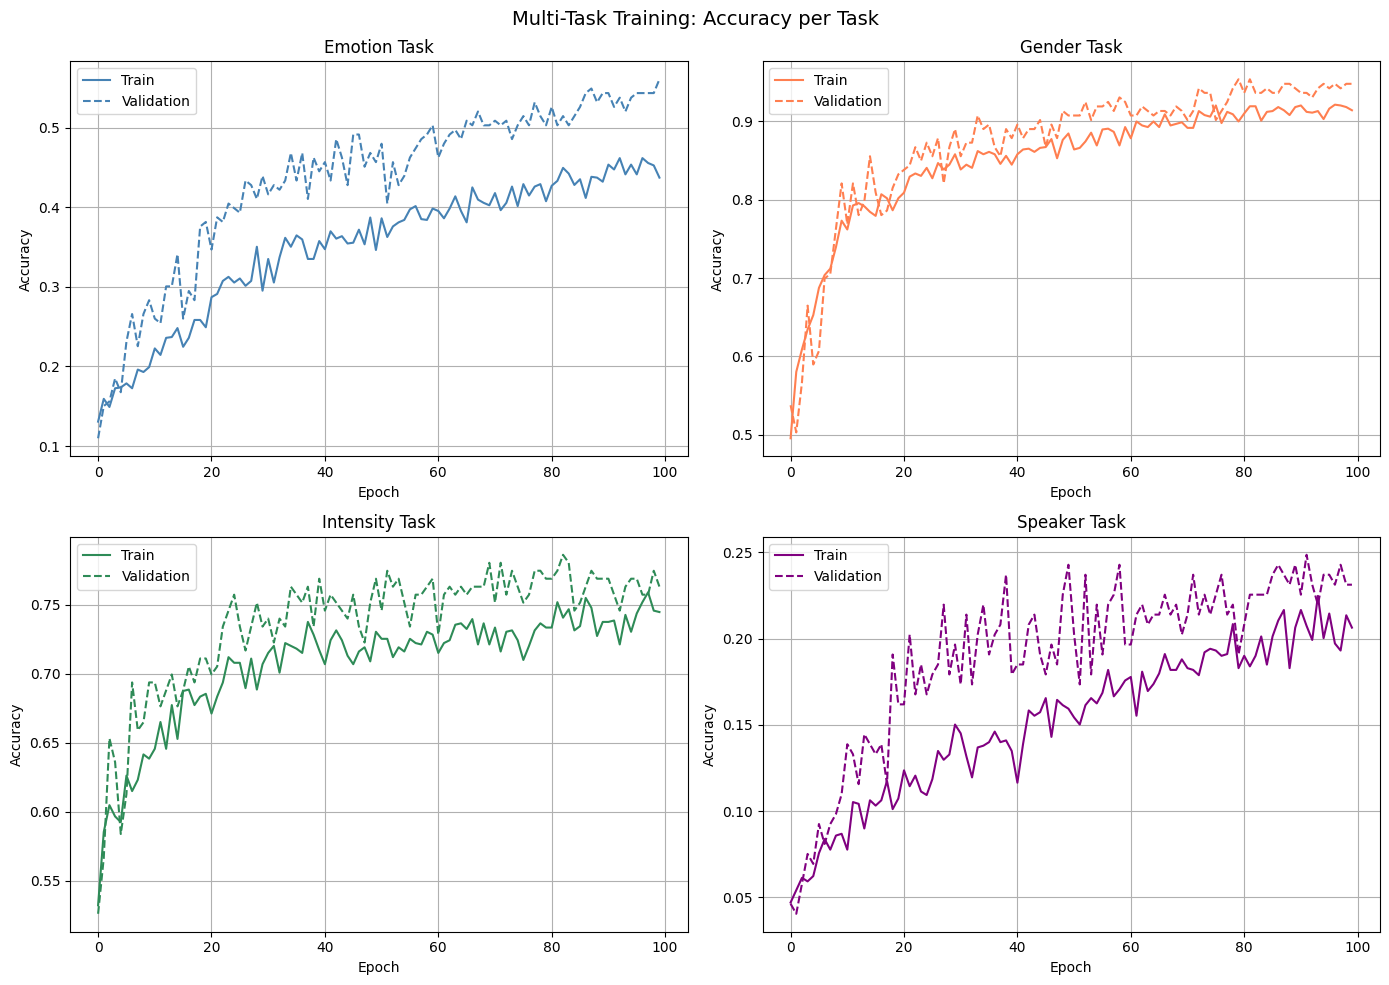

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
tasks = ['emotion', 'gender', 'intensity', 'speaker']
colors = ['steelblue', 'coral', 'seagreen', 'purple']

for ax, task, color in zip(axes.flatten(), tasks, colors):
    ax.plot(history[f'train_{task}'], label='Train', color=color)
    ax.plot(history[f'val_{task}'], label='Validation', color=color, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{task.capitalize()} Task')
    ax.legend()
    ax.grid(True)

plt.suptitle('Multi-Task Training: Accuracy per Task', fontsize=14)
plt.tight_layout()
plt.savefig('multitask_training_curves.png', dpi=150)
plt.show()

## 7. Evaluation

In [ ]:
test_losses, test_accs = evaluate(model, test_loader, criterion, device, LOSS_WEIGHTS)

print("Test Results:")
for task in LOSS_WEIGHTS:
    print(f"  {task.capitalize()} Accuracy: {test_accs[task]:.4f}")

Test Results:
  Emotion Accuracy: 0.4132
  Gender Accuracy: 0.9410
  Intensity Accuracy: 0.7500
  Speaker Accuracy: 0.1979


In [ ]:
# Get emotion predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y_em, _, _, _ in test_loader:
        X = X.to(device)
        outputs = model(X)
        _, predicted = outputs['emotion'].max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_em.numpy())

print("\nEmotion Classification Report:")
print(classification_report(all_labels, all_preds, target_names=encoders['emotion'].classes_))


Emotion Classification Report:
              precision    recall  f1-score   support

       angry       0.40      0.47      0.43        38
        calm       0.57      0.71      0.64        38
     disgust       0.57      0.66      0.61        38
     fearful       0.35      0.31      0.33        39
       happy       0.00      0.00      0.00        39
     neutral       0.32      0.37      0.34        19
         sad       0.22      0.21      0.22        38
   surprised       0.39      0.56      0.46        39

    accuracy                           0.41       288
   macro avg       0.35      0.41      0.38       288
weighted avg       0.35      0.41      0.38       288



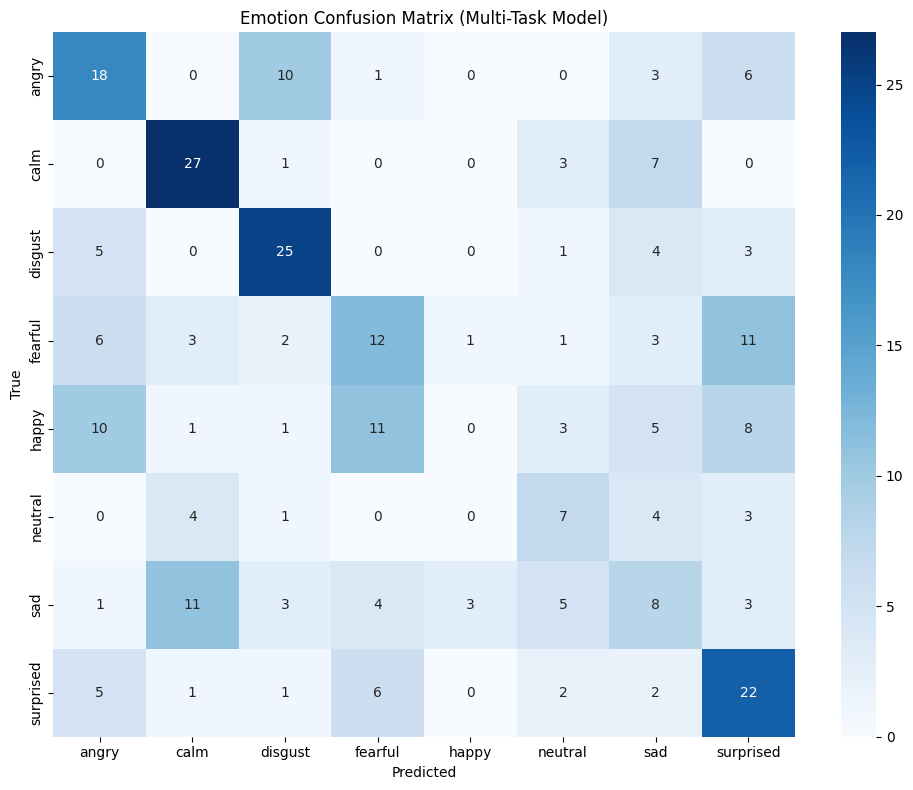

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoders['emotion'].classes_,
            yticklabels=encoders['emotion'].classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Emotion Confusion Matrix (Multi-Task Model)')
plt.tight_layout()
plt.savefig('multitask_emotion_confusion_matrix.png', dpi=150)
plt.show()